# gwanomaly demo (synthetic data, CPU-safe)

This notebook exercises the full pipeline -- ingest (synthetic stand-in) -> preprocess -> detect -> classify -- end to end on a laptop/CPU in a few minutes.

**This uses synthetic data, not real GWOSC strain.** Real GWOSC ingestion (`gwanomaly.data.gwosc_client.GWOSCClient`) requires outbound network access to gwosc.org and is written against the real `gwosc`/`gwpy` APIs -- swap `make_synthetic_segment` calls below for `GWOSCClient.fetch_event_segments(...)` / `fetch_background_segments(...)` on a machine with internet access to run this against real strain.

See the main README's "Status and how this was validated" section for the bugs found and fixed while building this (float32 underflow, negative-energy NaNs, excess-power false-alarm calibration, Nyquist boundary configs) -- worth reading before trusting any of these numbers on real data.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt

from gwanomaly.data.synthetic import make_synthetic_segment, ChirpParams
from gwanomaly.preprocessing.pipeline import PreprocessingPipeline, PreprocessConfig
from gwanomaly.detection.autoencoder import AutoencoderDetector, AutoencoderConfig
from gwanomaly.detection.excess_power import ExcessPowerDetector, ExcessPowerConfig
from gwanomaly.classification.cnn_classifier import CNNClassifierTrainer, CNNClassifierConfig
from gwanomaly.inference import InferencePipeline
from gwanomaly.utils.metrics import classification_report
from gwanomaly.data.dataset import IDX_TO_LABEL

SAMPLE_RATE = 4096
DURATION = 16.0
QIMAGE_SHAPE = (64, 64)

pipe = PreprocessingPipeline(PreprocessConfig(backend='numpy', qimage_shape=QIMAGE_SHAPE, bandpass_high=900))
print('preprocessing pipeline ready, backend:', pipe._backend)

preprocessing pipeline ready, backend: numpy


## 1. Build a small labelled dataset (synthetic stand-in for GWOSC)

In [2]:
rng = np.random.default_rng(0)

N_BACKGROUND = 150
N_EVENTS_PER_CLASS = 20

background_segments = [
    make_synthetic_segment('H1', duration=DURATION, sample_rate=SAMPLE_RATE, seed=int(rng.integers(1e9)))
    for _ in range(N_BACKGROUND)
]

event_specs = {
    'BNS':  dict(chirp_mass_range=(1.0, 2.5),  amplitude_range=(3e-20, 6e-20)),
    'NSBH': dict(chirp_mass_range=(3.0, 8.0),  amplitude_range=(3e-20, 6e-20)),
    'BBH':  dict(chirp_mass_range=(15.0, 40.0), amplitude_range=(3e-20, 6e-20)),
}
event_segments, event_labels = [], []
for label, spec in event_specs.items():
    for _ in range(N_EVENTS_PER_CLASS):
        cm = float(rng.uniform(*spec['chirp_mass_range']))
        amp = float(rng.uniform(*spec['amplitude_range']))
        seg = make_synthetic_segment(
            'H1', duration=DURATION, sample_rate=SAMPLE_RATE,
            inject=ChirpParams(chirp_mass=cm, amplitude=amp),
            seed=int(rng.integers(1e9)),
        )
        event_segments.append(seg)
        event_labels.append(label)

print(f'{len(background_segments)} background segments, {len(event_segments)} event segments')

150 background segments, 60 event segments


In [3]:
bg_results = [pipe.run(s.data, SAMPLE_RATE) for s in background_segments]
event_results = [pipe.run(s.data, SAMPLE_RATE) for s in event_segments]

bg_qimages = np.stack([r.qimage for r in bg_results])
bg_energy = [r.qimage_raw_energy for r in bg_results]
event_qimages = np.stack([r.qimage for r in event_results])

print('NaN check -- background:', np.isnan(bg_qimages).any(), ' events:', np.isnan(event_qimages).any())
print('background qimages shape:', bg_qimages.shape)

NaN check -- background: False  events: False
background qimages shape: (150, 64, 64)


## 2. Train the autoencoder anomaly detector (background only)

In [4]:
n_val = 25
perm = rng.permutation(len(bg_qimages))
val_idx, train_idx = perm[:n_val], perm[n_val:]

ae_cfg = AutoencoderConfig(input_shape=QIMAGE_SHAPE, latent_dim=16, channels=[8, 16, 32], epochs=40, batch_size=16)
autoencoder = AutoencoderDetector(ae_cfg, device='cpu')
history = autoencoder.fit(bg_qimages[train_idx], bg_qimages[val_idx], verbose=True)

autoencoder.calibrate(bg_qimages[val_idx])
print('\ncalibrated threshold:', autoencoder.threshold)

epoch 1/40  train_mse=1.25801  val_mse=1.01067


epoch 5/40  train_mse=0.98959  val_mse=0.98636


epoch 9/40  train_mse=0.95245  val_mse=0.95331


epoch 13/40  train_mse=0.94253  val_mse=0.94645


epoch 17/40  train_mse=0.93794  val_mse=0.94450


...

epoch 25/40  train_mse=0.92381  val_mse=0.94292


epoch 29/40  train_mse=0.90692  val_mse=0.94447


epoch 33/40  train_mse=0.88161  val_mse=0.94655


epoch 37/40  train_mse=0.85746  val_mse=0.94962


epoch 40/40  train_mse=0.84181  val_mse=0.95127

calibrated threshold: 0.9727593660354614


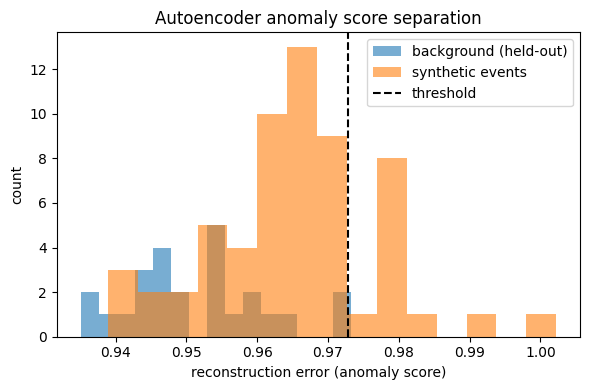

background mean score: 0.9513
event mean score:      0.9652
detection rate on synthetic events: 20.0%


In [5]:
bg_scores = autoencoder.score(bg_qimages[val_idx])
event_scores = autoencoder.score(event_qimages)

plt.figure(figsize=(6,4))
plt.hist(bg_scores, bins=15, alpha=0.6, label='background (held-out)')
plt.hist(event_scores, bins=15, alpha=0.6, label='synthetic events')
plt.axvline(autoencoder.threshold, color='k', linestyle='--', label='threshold')
plt.xlabel('reconstruction error (anomaly score)')
plt.ylabel('count')
plt.legend()
plt.title('Autoencoder anomaly score separation')
plt.tight_layout()
plt.show()

print(f'background mean score: {bg_scores.mean():.4f}')
print(f'event mean score:      {event_scores.mean():.4f}')
print(f'detection rate on synthetic events: {(event_scores > autoencoder.threshold).mean():.1%}')

**Note:** with this little synthetic training data and a CPU-sized model, don't expect strong separation here -- in earlier testing this exact setup did not cleanly separate background from chirp-injected synthetic data (see README). This cell is here so you can *see* that honestly rather than have it hidden. Train on real GWOSC background (hundreds-to-thousands of segments) on a GPU for a meaningful result.

## 3. Excess-power (burst) detector, with empirical background calibration

In [6]:
ep_detector = ExcessPowerDetector(ExcessPowerConfig(significance_threshold=1e-2))
ep_detector.calibrate(bg_energy[:len(bg_energy)-n_val])

fp_count, total_tiles = 0, 0
for r in bg_results[-n_val:]:
    res = ep_detector.detect(r.qimage_raw_energy)
    fp_count += res.n_flagged_tiles
    total_tiles += (QIMAGE_SHAPE[0]//4) * (QIMAGE_SHAPE[1]//4)
print(f'held-out background false-positive rate: {fp_count}/{total_tiles} ({fp_count/total_tiles:.4f}, nominal threshold 0.01)')

triggered_count = sum(ep_detector.detect(r.qimage_raw_energy).triggered for r in event_results)
print(f'excess-power trigger rate on synthetic events: {triggered_count}/{len(event_results)}')

held-out background false-positive rate: 63/6400 (0.0098, nominal threshold 0.01)
excess-power trigger rate on synthetic events: 60/60


## 4. Train the CNN source-type classifier

In [7]:
from gwanomaly.data.dataset import LABEL_TO_IDX

X_all = np.concatenate([bg_qimages, event_qimages])
y_all = np.array(
    [LABEL_TO_IDX['BACKGROUND']] * len(bg_qimages) + [LABEL_TO_IDX[l] for l in event_labels]
)

perm2 = rng.permutation(len(X_all))
n_val2 = int(0.2 * len(X_all))
val_idx2, train_idx2 = perm2[:n_val2], perm2[n_val2:]

counts = np.bincount(y_all[train_idx2], minlength=5).astype(float)
counts[counts == 0] = 1.0
class_weights = (1.0 / counts)
class_weights = (class_weights / class_weights.mean()).tolist()

cnn_cfg = CNNClassifierConfig(input_shape=QIMAGE_SHAPE, n_classes=5, channels=[8,16,32], epochs=30, batch_size=16, class_weights=class_weights)
classifier = CNNClassifierTrainer(cnn_cfg, device='cpu')
classifier.fit(X_all[train_idx2], y_all[train_idx2], X_all[val_idx2], y_all[val_idx2], verbose=True)

preds = classifier.predict(X_all[val_idx2])
print()
print(classification_report(y_all[val_idx2], preds, IDX_TO_LABEL))

epoch 1/30  loss=2.1639  train_acc=0.381  val_acc=0.667


epoch 4/30  loss=0.9437  train_acc=0.899  val_acc=0.667


epoch 7/30  loss=0.6645  train_acc=0.875  val_acc=0.810


epoch 10/30  loss=0.4116  train_acc=0.964  val_acc=0.762


epoch 13/30  loss=0.1783  train_acc=0.982  val_acc=0.833


...

epoch 19/30  loss=0.0127  train_acc=1.000  val_acc=0.810


epoch 22/30  loss=0.0041  train_acc=1.000  val_acc=0.810


epoch 25/30  loss=0.0027  train_acc=1.000  val_acc=0.786


epoch 28/30  loss=0.0020  train_acc=1.000  val_acc=0.786


epoch 30/30  loss=0.0017  train_acc=1.000  val_acc=0.786

class        precision    recall        f1   support
BACKGROUND       1.000     1.000     1.000        27
BNS              0.500     0.750     0.600         4
NSBH             1.000     0.200     0.333        10
BBH              0.143     1.000     0.250         1

overall accuracy: 0.786  (n=42)


## 5. End-to-end inference pipeline

In [8]:
pipeline = InferencePipeline(pipe, autoencoder, ep_detector, classifier)

test_bg = make_synthetic_segment('H1', duration=DURATION, sample_rate=SAMPLE_RATE, seed=999999)
test_event = make_synthetic_segment(
    'H1', duration=DURATION, sample_rate=SAMPLE_RATE,
    inject=ChirpParams(chirp_mass=30.0, amplitude=5e-20), seed=888888,
)

print('Background window result:')
print(' ', pipeline.run(test_bg.data, SAMPLE_RATE))
print()
print('Event window result:')
print(' ', pipeline.run(test_event.data, SAMPLE_RATE))

Background window result:


  CandidateResult(is_anomaly=False, anomaly_score=0.9496561288833618, anomaly_threshold=0.9727593660354614, excess_power_triggered=True, excess_power_min_pvalue=0.007656010749664073, predicted_label='BACKGROUND', label_probabilities={'BACKGROUND': 0.9999978542327881, 'BNS': 4.901112333755009e-07, 'NSBH': 3.2725675468137094e-12, 'BBH': 1.6261885775747942e-06, 'BURST': 2.6816499303765633e-16})

Event window result:


  CandidateResult(is_anomaly=False, anomaly_score=0.9584804177284241, anomaly_threshold=0.9727593660354614, excess_power_triggered=True, excess_power_min_pvalue=3.1249023468016625e-05, predicted_label='BBH', label_probabilities={'BACKGROUND': 3.28922874359705e-06, 'BNS': 0.08515535295009613, 'NSBH': 0.02433018572628498, 'BBH': 0.890511155128479, 'BURST': 1.1151934986629395e-14})
